<a href="https://colab.research.google.com/github/pradnyakawalkar/Session_assignment/blob/main/optional_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/hotel_bookings.csv")

Saving hotel_bookings.csv to hotel_bookings (1).csv


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
print("Shape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nInformation")
df.info()

Shape of Dataset
(119390, 32)

Columns
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Data Types
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_num

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
print("Duplicate Rows :",df.duplicated().sum())

df = df.drop_duplicates()

print(df.shape)

Duplicate Rows : 31994
(87396, 32)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,-0.615724,3.045939,-1.764027,July,0.011822,-1.676896,-0.974172,-1.278453,0.198253,...,No Deposit,NaN,NaN,-0.074839,Transient,-1.932925,-0.29917,-0.839684,Check-Out,2015-07-01
1,Resort Hotel,-0.615724,7.636196,-1.764027,July,0.011822,-1.676896,-0.974172,-1.278453,0.198253,...,No Deposit,NaN,NaN,-0.074839,Transient,-1.932925,-0.29917,-0.839684,Check-Out,2015-07-01
2,Resort Hotel,-0.615724,-0.847064,-1.764027,July,0.011822,-1.676896,-0.974172,-0.791496,-1.397925,...,No Deposit,NaN,NaN,-0.074839,Transient,-0.569627,-0.29917,-0.839684,Check-Out,2015-07-02
3,Resort Hotel,-0.615724,-0.777338,-1.764027,July,0.011822,-1.676896,-0.974172,-0.791496,-1.397925,...,No Deposit,1.854108,NaN,-0.074839,Transient,-0.569627,-0.29917,-0.839684,Check-Out,2015-07-02
4,Resort Hotel,-0.615724,-0.765717,-1.764027,July,0.011822,-1.676896,-0.974172,-0.304540,0.198253,...,No Deposit,1.288674,NaN,-0.074839,Transient,-0.151549,-0.29917,0.362324,Check-Out,2015-07-03


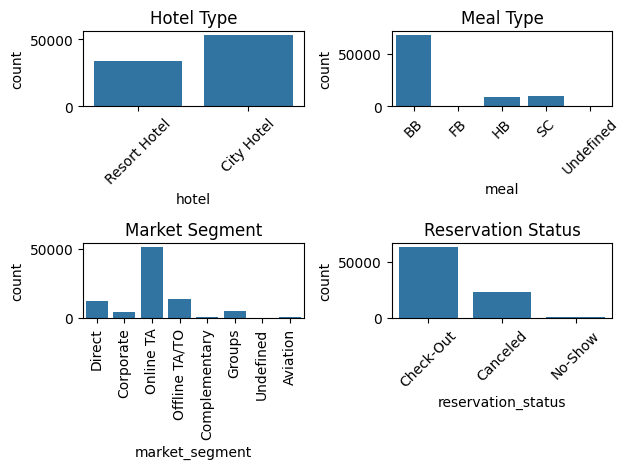

In [9]:


plt.subplot(2,2,1)
sns.countplot(x='hotel', data=df)
plt.title("Hotel Type")
plt.xticks(rotation=45)

plt.subplot(2,2,2)
sns.countplot(x='meal', data=df)
plt.title("Meal Type")
plt.xticks(rotation=45)

plt.subplot(2,2,3)
sns.countplot(x='market_segment', data=df)
plt.title("Market Segment")
plt.xticks(rotation=90)

plt.subplot(2,2,4)
sns.countplot(x='reservation_status', data=df)
plt.title("Reservation Status")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

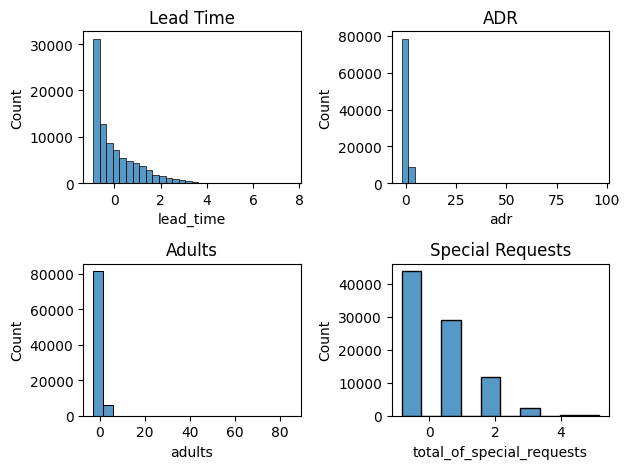

In [11]:


plt.subplot(2,2,1)
sns.histplot(df['lead_time'], bins=30)
plt.title("Lead Time")

plt.subplot(2,2,2)
sns.histplot(df['adr'], bins=30)
plt.title("ADR")

plt.subplot(2,2,3)
sns.histplot(df['adults'], bins=20)
plt.title("Adults")

plt.subplot(2,2,4)
sns.histplot(df['total_of_special_requests'], bins=10)
plt.title("Special Requests")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'ADR')

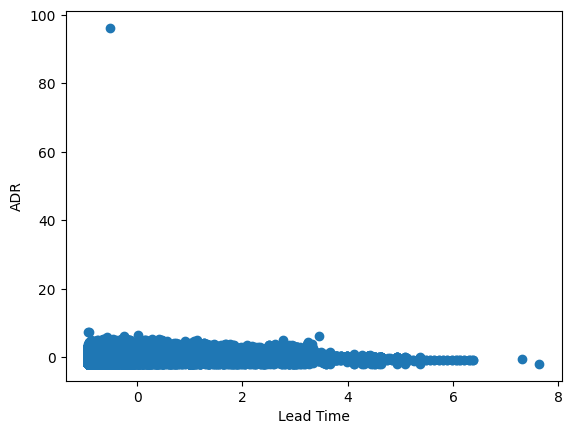

In [13]:


plt.scatter(df["lead_time"],df["adr"])

plt.xlabel("Lead Time")
plt.ylabel("ADR")



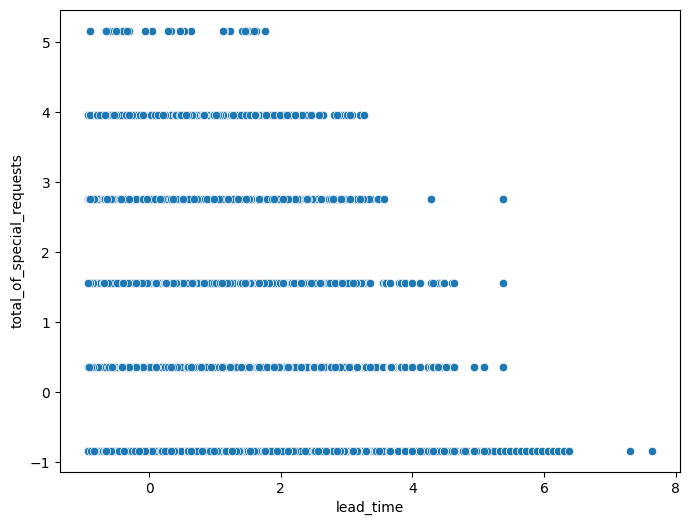

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="lead_time",
                y="total_of_special_requests",
                data=df)

plt.show()

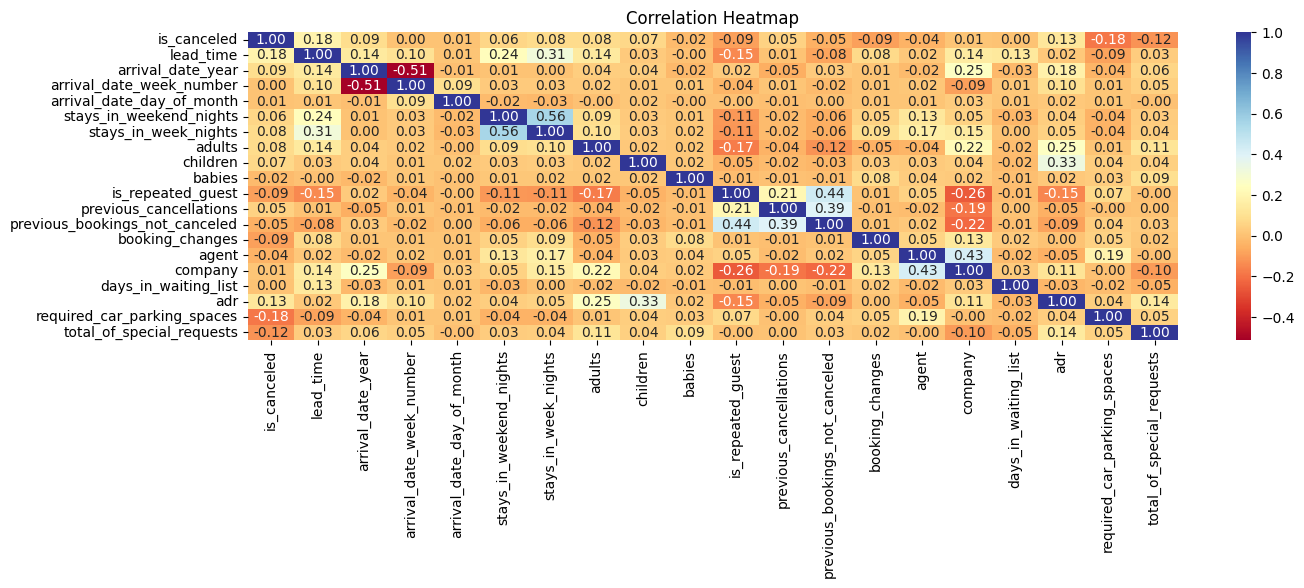

In [19]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(15,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

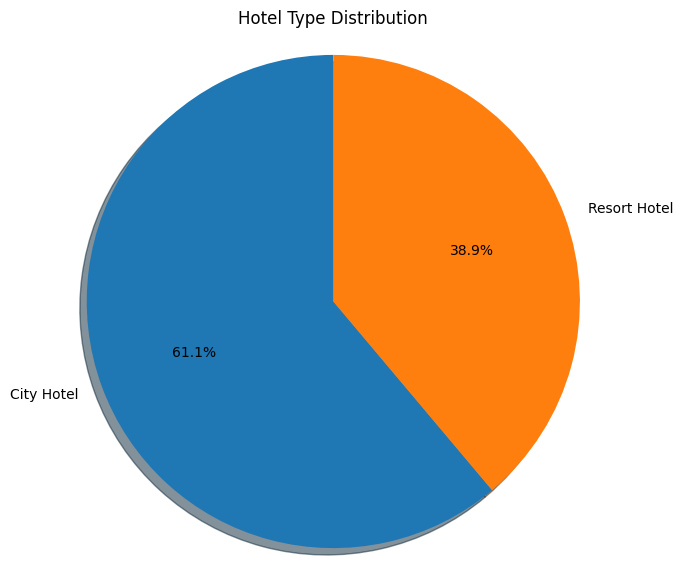

In [22]:
import matplotlib.pyplot as plt

hotel_counts = df['hotel'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    hotel_counts,
    labels=hotel_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Hotel Type Distribution")
plt.axis('equal')

plt.show()

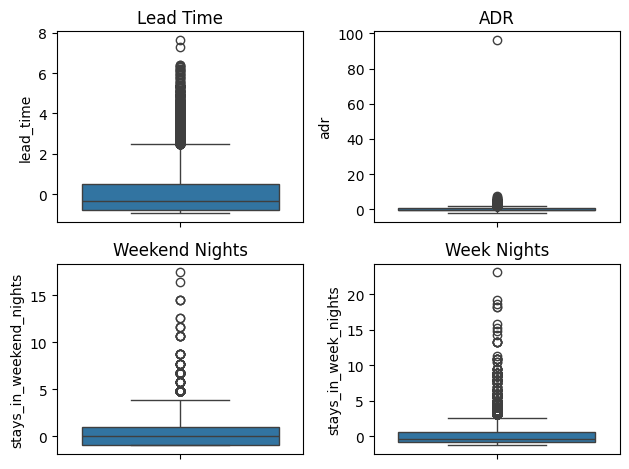

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns



# Box Plot 1
plt.subplot(2,2,1)
sns.boxplot(data=df, y='lead_time')
plt.title("Lead Time")

# Box Plot 2
plt.subplot(2,2,2)
sns.boxplot(data=df, y='adr')
plt.title("ADR")

# Box Plot 3
plt.subplot(2,2,3)
sns.boxplot(data=df, y='stays_in_weekend_nights')
plt.title("Weekend Nights")

# Box Plot 4
plt.subplot(2,2,4)
sns.boxplot(data=df, y='stays_in_week_nights')
plt.title("Week Nights")

plt.tight_layout()
plt.show()